# Semana 2, clase 2: mínimos cuadrados desde cero

Vamos a conectar cinco objetos que deben significar lo mismo en el tablero, el código y la biblioteca:

\[
\widehat y=X\theta,\qquad r=y-\widehat y,\qquad
J(\theta)=\frac{1}{2m}\lVert X\theta-y\rVert_2^2,\qquad
\nabla J(\theta)=\frac{1}{m}X^\top(X\theta-y).
\]

La cantidad poblacional es

\[
R_P(\theta)=\mathbb E_P[(Y-X^\top\theta)^2],
\]

mientras que `J` es una versión empírica escalada calculada con una muestra. Por eso `theta_hat`, el MSE de test y los residuales cambian si cambia la muestra, aunque el código sea idéntico.

La ecuación normal describe el óptimo. Para calcularlo usaremos `np.linalg.lstsq`, que evita formar explícitamente \(X^\top X\).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 2105
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Funciones pequeñas, convenciones explícitas

`add_intercept` añade una primera columna de unos. Todas las funciones exigen una matriz bidimensional y usan la convención residual \(r=y-X\theta\).

In [2]:
def add_intercept(X):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X debe ser una matriz bidimensional")
    return np.column_stack([np.ones(X.shape[0]), X])


def predict_linear(X, theta):
    X = np.asarray(X, dtype=float)
    theta = np.asarray(theta, dtype=float)
    return X @ theta


def half_mse_loss(X, y, theta):
    y = np.asarray(y, dtype=float)
    errores = predict_linear(X, theta) - y
    return 0.5 * np.mean(errores**2)


def mse_gradient(X, y, theta):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    errores = predict_linear(X, theta) - y
    return X.T @ errores / X.shape[0]


def fit_lstsq(X, y):
    theta, _, rank, singular_values = np.linalg.lstsq(X, y, rcond=None)
    return theta, rank, singular_values

## 2. Ejemplo controlado

Empezamos con cuatro observaciones y una sola variable. El pequeño ruido evita una recta perfecta y permite inspeccionar residuales.

In [3]:
x = np.array([[0.0], [1.0], [2.0], [3.0]])
y = np.array([1.1, 2.9, 5.2, 6.8])
X = add_intercept(x)

print("X =")
print(X)
print("Forma de X:", X.shape)

X =
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]]
Forma de X: (4, 2)


In [4]:
theta_candidato = np.array([1.0, 2.0])
pred_candidato = predict_linear(X, theta_candidato)
residual_candidato = y - pred_candidato

tabla_candidato = pd.DataFrame(
    {
        "x": x.ravel(),
        "y": y,
        "ŷ": pred_candidato,
        "r = y - ŷ": residual_candidato,
    }
)
display(tabla_candidato)
print(f"J(theta_candidato) = {half_mse_loss(X, y, theta_candidato):.5f}")
print("Gradiente =", mse_gradient(X, y, theta_candidato))

,x,y,ŷ,r = y - ŷ
0,0.0,1.1,1.0,0.1
1,1.0,2.9,3.0,-0.1
2,2.0,5.2,5.0,0.2
3,3.0,6.8,7.0,-0.2


J(theta_candidato) = 0.01250
Gradiente = [0.    0.075]


**Pausa de tablero.** Compruebe las formas antes de calcular:

\[
X\in\mathbb R^{4\times 2},\quad \theta\in\mathbb R^2,\quad
X\theta-y\in\mathbb R^4,\quad X^\top(X\theta-y)\in\mathbb R^2.
\]

El gradiente apunta hacia el aumento más rápido de la pérdida; para reducirla se avanza en la dirección opuesta.

## 3. Gradiente: comprobación numérica

Una diferencia central aproxima cada derivada parcial. No reemplaza la derivación, pero detecta errores de signo, factores o formas.

In [5]:
def finite_difference_gradient(loss_fn, theta, epsilon=1e-6):
    theta = np.asarray(theta, dtype=float)
    grad = np.zeros_like(theta)
    for j in range(theta.size):
        step = np.zeros_like(theta)
        step[j] = epsilon
        grad[j] = (loss_fn(theta + step) - loss_fn(theta - step)) / (2 * epsilon)
    return grad


grad_analitico = mse_gradient(X, y, theta_candidato)
grad_numerico = finite_difference_gradient(
    lambda theta: half_mse_loss(X, y, theta),
    theta_candidato,
)

print("Analítico:", grad_analitico)
print("Numérico: ", grad_numerico)
print("Diferencia máxima:", np.max(np.abs(grad_analitico - grad_numerico)))

Analítico: [0.    0.075]
Numérico:  [3.46944695e-12 7.50000000e-02]
Diferencia máxima: 1.172117958248009e-11


## 4. Ecuaciones normales y cálculo robusto

En un óptimo de mínimos cuadrados, el gradiente es cero:

\[
X^\top(X\widehat\theta-y)=0
\quad\Longleftrightarrow\quad
X^\top X\widehat\theta=X^\top y.
\]

Esta igualdad es la **ecuación normal**. No obliga a calcular \((X^\top X)^{-1}\). `lstsq` resuelve el problema de mínimos cuadrados con una factorización numérica más estable y también informa el rango.

In [6]:
theta_lstsq, rank, singular_values = fit_lstsq(X, y)
pred_lstsq = predict_linear(X, theta_lstsq)
residual = y - pred_lstsq

print("theta_lstsq:", theta_lstsq)
print("rango:", rank)
print("valores singulares:", singular_values)
print("X.T @ residual:", X.T @ residual)
print("norma del gradiente:", np.linalg.norm(mse_gradient(X, y, theta_lstsq)))

theta_lstsq: [1.09 1.94]
rango: 2
valores singulares: [4.10003045 1.09075677]
X.T @ residual: [-1.33226763e-15 -2.22044605e-15]
norma del gradiente: 6.473657049138938e-16


La condición \(X^\top r\approx 0\) expresa que el residual queda ortogonal a cada columna de la matriz de diseño. El símbolo \(\approx\) reconoce el redondeo de punto flotante.

In [7]:
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(x, y)
theta_sklearn = np.r_[modelo_sklearn.intercept_, modelo_sklearn.coef_]

comparacion_theta = pd.DataFrame(
    {
        "parámetro": ["intercepto", "pendiente"],
        "lstsq": theta_lstsq,
        "scikit-learn": theta_sklearn,
    }
)
display(comparacion_theta)
print("Máxima diferencia:", np.max(np.abs(theta_lstsq - theta_sklearn)))

,parámetro,lstsq,scikit-learn
0,intercepto,1.09,1.09
1,pendiente,1.94,1.94


Máxima diferencia: 2.220446049250313e-16


## 5. Por qué no formar \(X^\top X\) sin necesidad

En norma 2, si \(X\) tiene rango columna completo,

\[
\kappa_2(X^\top X)=\kappa_2(X)^2.
\]

Formar \(X^\top X\) puede amplificar un problema de condicionamiento. La ecuación normal sigue siendo correcta como caracterización matemática; `lstsq` es la opción computacional preferida aquí.

In [8]:
condicion_X = np.linalg.cond(X)
condicion_XtX = np.linalg.cond(X.T @ X)
print(f"kappa(X)      = {condicion_X:.6f}")
print(f"kappa(X.T@X)  = {condicion_XtX:.6f}")
print(f"kappa(X)^2    = {condicion_X**2:.6f}")

kappa(X)      = 3.758886
kappa(X.T@X)  = 14.129225
kappa(X)^2    = 14.129225


## 6. Caso de Bogotá: 32 subzonas

El recurso oficial de vivienda nueva contiene observaciones agregadas. En el subconjunto congelado para el curso, cada fila es una **subzona**, no una vivienda. El archivo fuente llama `precios` a la variable objetivo, pero no documenta su unidad; por eso usamos el nombre `precio_reportado` y no interpretamos pesos, millones ni precio por metro cuadrado.

In [9]:
def find_course_data(filename):
    candidates = [
        Path("libro_curso/datos") / filename,
        Path("datos") / filename,
        Path("../libro_curso/datos") / filename,
        Path("../../libro_curso/datos") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"No se encontró {filename}. Ejecute el notebook desde la raíz del curso "
        "o conserve la carpeta datos del paquete offline."
    )


data_path = find_course_data("vivienda_nueva_bogota_subzonas.csv")
bogota = pd.read_csv(data_path)
print("Archivo:", data_path)
display(bogota.head())
print("Forma:", bogota.shape)

Archivo: libro_curso/datos/vivienda_nueva_bogota_subzonas.csv


,subzona,precio_reportado,estrato_promedio,area_promedio,alcobas_promedio,banos_promedio,parqueaderos_promedio
0,Rosales,16.364833,5.921512,177.315698,2.672965,3.776163,2.981105
1,Chico,13.939057,5.905213,128.043839,2.225118,3.104660,2.152449
2,Bosque Medina,10.751194,4.699140,151.226361,2.532951,3.037249,2.467049
3,Multicentro,10.365171,5.647236,94.070728,2.086314,2.625469,1.785589
4,La Carolina,10.050658,5.390084,114.054818,2.179607,2.956034,1.985033


Forma: (32, 7)


In [10]:
features = [
    "estrato_promedio",
    "area_promedio",
    "alcobas_promedio",
    "banos_promedio",
    "parqueaderos_promedio",
]
target = "precio_reportado"

X_bogota = bogota[features]
y_bogota = bogota[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_bogota,
    y_bogota,
    test_size=0.25,
    random_state=RANDOM_STATE,
)
print({"train": len(y_train), "test": len(y_test)})

{'train': 24, 'test': 8}


## 7. Baseline, modelo y residuales fuera del ajuste

El baseline predice para toda subzona de test la media de `precio_reportado` observada en entrenamiento. El modelo lineal usa las cinco variables numéricas. La comparación tiene solo ocho filas de test: es un ejemplo docente, no una validación para uso operativo.

In [11]:
pred_baseline = np.full(len(y_test), y_train.mean())

modelo_bogota = LinearRegression()
modelo_bogota.fit(X_train, y_train)
pred_modelo = modelo_bogota.predict(X_test)

metricas = pd.DataFrame(
    {
        "método": ["Media de entrenamiento", "Regresión lineal"],
        "MAE": [
            mean_absolute_error(y_test, pred_baseline),
            mean_absolute_error(y_test, pred_modelo),
        ],
        "RMSE": [
            mean_squared_error(y_test, pred_baseline) ** 0.5,
            mean_squared_error(y_test, pred_modelo) ** 0.5,
        ],
    }
)
display(metricas.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}"}))

,método,MAE,RMSE
0,Media de entrenamiento,1.723,1.954
1,Regresión lineal,0.615,0.647


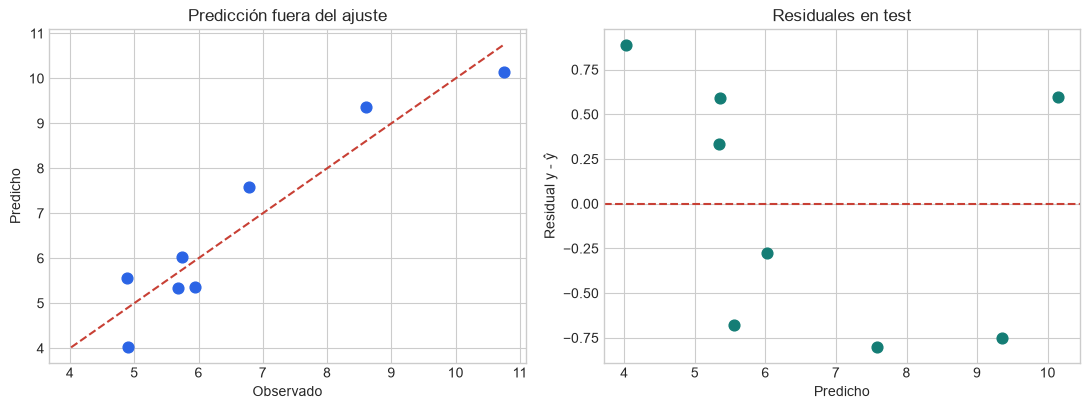

In [12]:
residual_test = y_test.to_numpy() - pred_modelo
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(y_test, pred_modelo, color="#2b64e5", s=60)
low = min(y_test.min(), pred_modelo.min())
high = max(y_test.max(), pred_modelo.max())
axes[0].plot([low, high], [low, high], "--", color="#c84035")
axes[0].set(xlabel="Observado", ylabel="Predicho", title="Predicción fuera del ajuste")

axes[1].scatter(pred_modelo, residual_test, color="#147d75", s=60)
axes[1].axhline(0, linestyle="--", color="#c84035")
axes[1].set(xlabel="Predicho", ylabel="Residual y - ŷ", title="Residuales en test")

plt.tight_layout()
plt.show()

## 8. La partición también introduce variación

Repetimos el mismo procedimiento con varias semillas. No usamos estas repeticiones para escoger la semilla más favorable; las usamos para ver cuánto depende el resultado de una muestra de test tan pequeña.

,semilla,MAE_baseline,MAE_modelo
0,2105,1.723,0.615
1,1,2.627,0.373
2,2,3.567,1.414
3,3,2.078,0.633
4,4,1.799,0.463
5,5,2.203,0.613
6,13,3.083,1.207
7,21,3.493,1.463


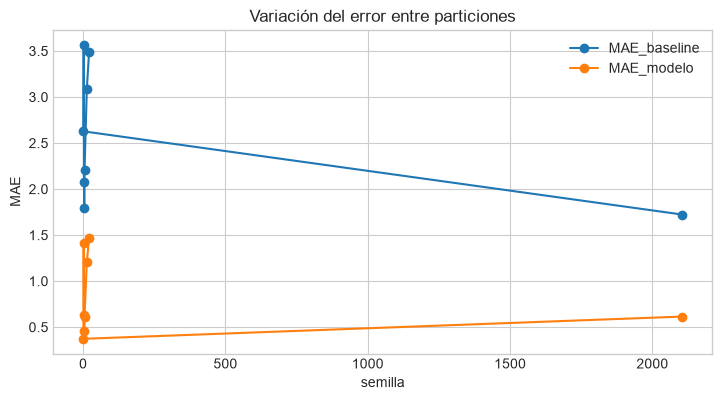

In [13]:
rows = []
for seed in [2105, 1, 2, 3, 4, 5, 13, 21]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_bogota,
        y_bogota,
        test_size=0.25,
        random_state=seed,
    )
    model = LinearRegression().fit(X_tr, y_tr)
    rows.append(
        {
            "semilla": seed,
            "MAE_baseline": mean_absolute_error(y_te, np.full(len(y_te), y_tr.mean())),
            "MAE_modelo": mean_absolute_error(y_te, model.predict(X_te)),
        }
    )

variacion = pd.DataFrame(rows)
display(variacion.round(3))
variacion.set_index("semilla").plot(marker="o", figsize=(8.5, 4.2))
plt.ylabel("MAE")
plt.title("Variación del error entre particiones")
plt.show()

## 9. Conclusión proporcionada

En la partición con semilla 2105, la regresión lineal reduce el MAE de **1.723** a **0.615** frente al baseline. Sin embargo, solo hay 32 subzonas, ocho quedan en test y el error cambia al modificar la partición. Además, la unidad del objetivo no está documentada en el recurso descargado.

Por tanto, el resultado sirve para estudiar matrices, predicciones y residuales; no basta para recomendar una política de vivienda ni para valorar una vivienda particular.

## 10. Pruebas de consistencia

Estas aserciones enlazan la derivación, la implementación propia y la biblioteca.

In [14]:
assert np.allclose(grad_analitico, grad_numerico, atol=1e-7)
assert np.linalg.norm(X.T @ residual) < 1e-10
assert np.allclose(theta_lstsq, theta_sklearn, atol=1e-12)
assert np.isclose(condicion_XtX, condicion_X**2)
assert bogota.shape == (32, 7)
assert metricas.loc[1, "MAE"] < metricas.loc[0, "MAE"]
assert np.isclose(metricas.loc[0, "MAE"], 1.722949354166667, atol=1e-9)
assert np.isclose(metricas.loc[1, "MAE"], 0.6146890184771725, atol=1e-9)
print("Comprobaciones superadas.")

Comprobaciones superadas.
